In [1]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchdiffeq import odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch


os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [2]:
sc.settings.set_figure_params(frameon=False, dpi=70, figsize=(3,3))

# Exp configs

In [3]:
# find all config files
config_dir = "logs/ery_mk_TM1/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

In [4]:
# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config_dict[version] = PINN.ExperimentConfig(os.path.join(config_dir, js))

In [5]:
for v,config in config_dict.items():
    print(v)
    print(config.find_lastest_ckpt())
    print("/n")

1
/ssd/users/Wergillius/Project/PINN_dynamics/logs/ery_mk_TM1/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=61-total_loss=0.90493035.ckpt
/n
4
/ssd/users/Wergillius/Project/PINN_dynamics/logs/ery_mk_TM1/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=45-total_loss=1.00738251.ckpt
/n
0
/ssd/users/Wergillius/Project/PINN_dynamics/logs/ery_mk_TM1/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=56-total_loss=0.88771957.ckpt
/n
2
/ssd/users/Wergillius/Project/PINN_dynamics/logs/ery_mk_TM1/pde_params_tsense/lightning_logs/version_2/checkpoints/epoch=53-total_loss=2.82354069.ckpt
/n
5
/ssd/users/Wergillius/Project/PINN_dynamics/logs/ery_mk_TM1/pde_params_tsense/lightning_logs/version_5/checkpoints/epoch=51-total_loss=1.18324518.ckpt
/n
3
/ssd/users/Wergillius/Project/PINN_dynamics/logs/ery_mk_TM1/pde_params_tsense/lightning_logs/version_3/checkpoints/epoch=52-total_loss=2.91234469.ckpt
/n


# load model and dataset

In [6]:
config.dataset_config

{'cellstate_key': 'DM_EigenVectors_multiscaled',
 'n_grid': 300,
 'n_dimension': 8,
 'kde_kws': {'bw_method': None},
 'timepoint_idx': [0, 1, 2, 3, 4, 6, 8],
 'deltax_key': 'Delta_DM',
 'norm_time': 'True'}

In [7]:
# # load dataset
dataset_name = config.experiment_config['dataset']
adata = sc.read_h5ad(f'data/{dataset_name}.h5ad')

In [8]:
ds_config = config.dataset_config.copy()
ds_config['timepoint_idx'] = None

full_DS = PINN.reader.TwoTimpepoint_AnnDS(adata,split=None,**ds_config)

# train_DS = PINN.reader.TwoTimpepoint_AnnDS(adata,split='train',**ds_config)
# val_DS = PINN.reader.TwoTimpepoint_AnnDS(adata,split='val',**ds_config)
# test_DS = PINN.reader.TwoTimpepoint_AnnDS(adata,split='test',**ds_config)

Computing density :
`density_funs` not specified, use gaussian kde
all cells are used


In [9]:
# load models
model_dict = {}
for v in config_dict:
    ckpt = config_dict[v].find_lastest_ckpt()
    model_dict[v] = PINN.models.pde_params.load_from_checkpoint(ckpt, map_location='cpu')

import cellrank as cr

In [10]:
import cellrank as cr

In [11]:
adata.obs['HSCscore'].argmin()

22259

In [12]:
adata.uns['iroot'] = adata.obs['HSCscore'].argmax()

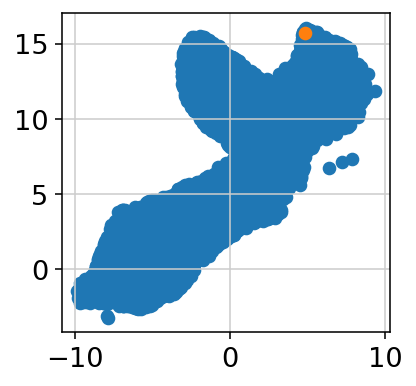

In [13]:
Xumap = adata.obsm['X_umap']
plt.scatter(Xumap[:,0], Xumap[:,1])
plt.scatter(Xumap[adata.uns['iroot'] ,0], Xumap[adata.uns['iroot'] ,1])

In [15]:
ck = cr.kernels.ConnectivityKernel(adata)
ck.compute_transition_matrix()

ConnectivityKernel[n=22740, dnorm=True, key='connectivities']

In [16]:
pk = cr.kernels.PseudotimeKernel(adata, time_key="palantir_pseudotime")
pk.compute_transition_matrix()

  0%|          | 0/22740 [00:00<?, ?cell/s]

PseudotimeKernel[n=22740, dnorm=False, scheme='hard', frac_to_keep=0.3]

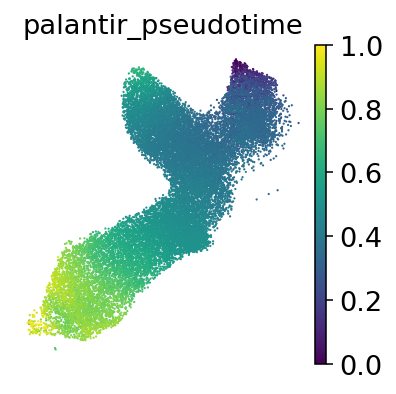

In [50]:
sc.pl.umap(adata, color='palantir_pseudotime')

In [17]:
combined_kernel = 0.8 * pk + 0.2 * ck
combined_kernel.compute_transition_matrix()

(0.8 * PseudotimeKernel[n=22740, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.2 * ConnectivityKernel[n=22740, dnorm=True, key='connectivities'])

In [51]:
adata.obsp['combined_transition_matrix'] = pk.transition_matrix

In [53]:
T_M = pk.transition_matrix

In [44]:
from PINN.functions import reader_funs

In [ ]:
cellstate_key = config.dataset_config['cellstate_key']
delta_DM, neighbors = reader_funs.sample_deltax_from_transition(adata, T_M, xkey=cellstate_key)

In [48]:
adata.obsm['Delta_DM_cr'] = delta_DM

# scvelo

In [19]:
import scvelo as scv

In [11]:
cellstate_key = config.dataset_config['cellstate_key']

In [12]:
pde_model = model_dict[v]

In [13]:
adata.obsm['Delta_DM'].shape

(22740, 8)

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

    finished (0:00:11) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:03) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


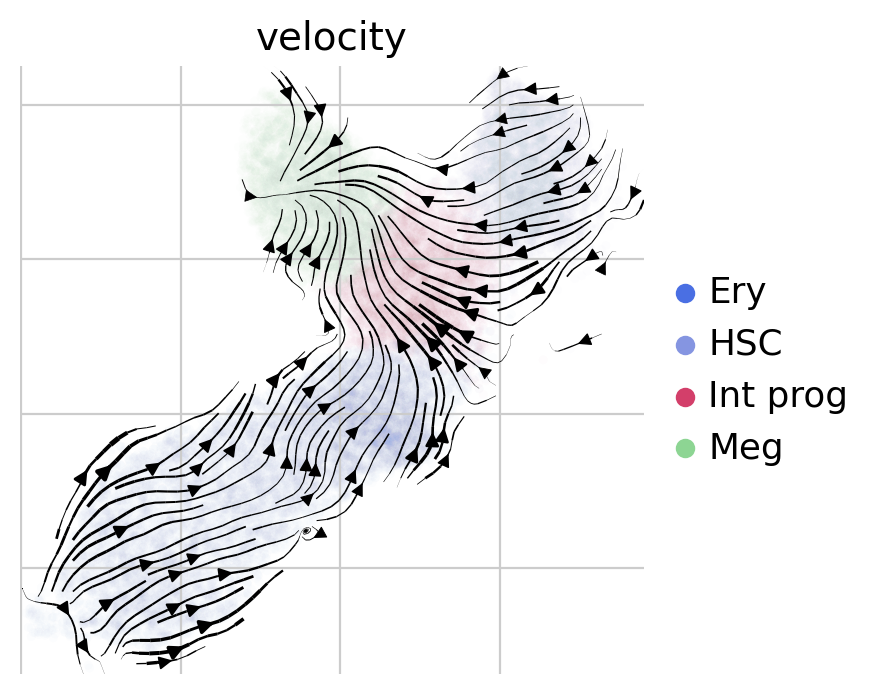

In [49]:
cellstate_ad = PINN.tl.make_coord_adata(adata, cellstate_key=cellstate_key, n_dimension=8)
sc.pp.neighbors(cellstate_ad, n_neighbors=15)

cellstate_ad.layers['velocity'] = adata.obsm['Delta_DM_cr'].copy()


# compute velocity graph
vkey = 'velocity'
scv.tl.velocity_graph(cellstate_ad,  vkey='velocity', xkey='cellstate', n_jobs=20)

# vis
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title=vkey, )
                                # save=f"{result_dir}/{vkey}_velo.png")

In [ ]:
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title=vkey, )
                                # save=f"{result_dir}/{vkey}_velo.png"
fig_velocity

In [ ]:
v_dict = {}
for v, pde_model in model_dict.items():
    g_pred_ay, v_pred_ay, D_pred_ay = pde_model.predict_param(full_DS)

    result_dir = config_dict[v].experiment_config['checkpoint_dir'].replace("logs","results").replace("lightning_logs/","")
    PINN.tl.make_dir(result_dir)
    print(result_dir)

    fig_g,axs = PINN.pl.params_in_umap(adata, g_pred_ay, param='g')
    fig_g.savefig(os.path.join(result_dir,'g.png'), transparent=True)
    fig_g.close()

    if D_pred_ay.shape[-1] == 1:
        fig_D,axs = PINN.pl.params_in_umap(adata, D_pred_ay.squeeze(), param='D')
        fig_D.savefig(os.path.join(result_dir,'D.png'), transparent=True)
        fig_D.close()

    v_pred_norm = np.sqrt(np.sum(v_pred_ay**2, axis=-1))
    fig_v,axs = PINN.pl.params_in_umap(adata, v_pred_norm, param='v')
    fig_v.savefig(os.path.join(result_dir,'v.png'), transparent=True)
    fig_v.close()

    # visualize like RNA velocity
    cellstate_ad = PINN.tl.make_coord_adata(adata, cellstate_key=cellstate_key, n_dimension=8, v = v_pred_ay)
    vkeys = [k for k in list(cellstate_ad.layers.keys()) if k.endswith("v")]
    sc.pp.neighbors(cellstate_ad, n_neighbors=15)

    for vkey in vkeys:

        # compute velocity graph
        scv.tl.velocity_graph(cellstate_ad,  vkey=vkey, xkey='cellstate', n_jobs=20)

        # vis
        fig_velocity = plt.figure(dpi=100, figsize=(4,4))
        ax = fig_velocity.gca()
        scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                        basis='umap', ax=ax, 
                                        legend_loc='right', alpha=0.01,
                                        title=vkey, 
                                        save=f"{result_dir}/{vkey}_velo.png")

/ssd/users/Wergillius/Project/PINN_dynamics/results/ery_mk_TM1/pde_params_tsense/lightning_results/version_1
prediction of shape (9, 22740)
prediction of shape (9, 22740)


computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

# simulate density and then evaluate

In [ ]:
v = '0'
performance_js = []
timepoints = adata.uns['pop']['t']
n_timepoints = timepoints.shape[0]

for v in model_dict:
    device = 'cuda:3'
    pde_model = model_dict[v].to(device).eval()
    u_b = test_DS.u_b.cpu().numpy()

    u_sim = PINN.tl.density_shortterm_simulation(pde_model, DataSet=test_DS, timepoints=adata.uns['pop']['t'])
    u_int_all = np.concatenate([u_b[0,None], u_sim], axis=0)

    KLD_ls = PINN.tl.KLD_density(u_b, u_int_all)
    W1 = PINN.tl.W_distance(u_b, u_int_all, p=1)
    W2 = PINN.tl.W_distance(u_b, u_int_all)

    df = pd.DataFrame({
        "v":[v]*n_timepoints, 'KLD':KLD_ls,
         'W1': W1, 'W2':W2,
         't':timepoints
        })
    performance_js.append(df)

# concat all df
density_performance_df = pd.concat(performance_js, axis=0)

In [74]:
density_performance_df.head()

,v,KLD,W1,W2,t
0,1,0.000000,0.000000,0.000000,3
1,1,0.032531,0.000059,0.000059,7
2,1,0.013427,0.000034,0.000034,12
3,1,0.022540,0.000172,0.000172,27
4,1,0.044639,0.000188,0.000188,49


In [75]:
density_performance_df.to_csv("logs/ery_mk_TM1/pde_params_tsense/density_perfomance.csv")

# simulate trajectory for HSC

In [12]:
HSC_ad = adata[adata.obs['anno_man']=='HSC'].copy()

init_s_by_time = {}

for t in HSC_ad.uns['pop']['t']:

    ad_t = HSC_ad[HSC_ad.obs['timepoint_tx_days']==t]
    s_init_t = ad_t.obsm[cellstate_key].copy()

    init_s_by_time[str(int(t))] = s_init_t

In [18]:
timepoint_tx_days = sorted(adata.obs.timepoint_tx_days.unique())
t0 = timepoint_tx_days[0]

In [ ]:
v = '0'
device = 'cuda:3'
n_interval = 9

simulated_trajactory = {}

pde_model = model_dict[v].to(device).eval()

DT = PINN.models.Density_Transfer(pde_model)

for t,s0 in init_s_by_time.items():
    t = int(t)
    integration_time = np.linspace(t/t0, (t+15)/t0 ,n_interval+1) / pde_model.time_scale_factor

    s_traj_t = DT.cellstate_drift(s0, integration_time)

    simulated_trajactory[str(t)] = s_traj_t

    # assign cell type
    nn_annotation = PINN.tl.assign_nearest_cell(s_traj_t[-1], adata, cellstate_key, n_dimension=8, annotation='anno_man')

In [ ]:
# Calculate the proportion of different labels for each time point (column)
label_proportions = nn_annotation.apply(lambda col: col.value_counts(normalize=True), axis=0)

# Transpose to have time points as rows and cell types as columns
# Fill NaN values with 0 (for cases where a cell type doesn't appear in a time point)
label_proportions = label_proportions.T.fillna(0)

print(label_proportions)

           HSC  Int prog       Meg
0     0.000000  0.000000  1.000000
1     0.000000  0.416667  0.583333
2     0.000000  0.000000  1.000000
3     0.000000  0.083333  0.916667
4     0.250000  0.333333  0.416667
...        ...       ...       ...
1165  0.000000  0.416667  0.583333
1166  0.000000  0.416667  0.583333
1167  0.000000  0.416667  0.583333
1168  0.000000  0.500000  0.500000
1169  0.333333  0.333333  0.333333

[1170 rows x 3 columns]


In [84]:
cellstate_key = config.dataset_config['cellstate_key']
timepoint_key = 'timepoint_tx_days'

t_list = train_DS.T_b

# Dynamic density transport

In [7]:
# go for all HSC cells
from torch import nn
import gc
import torch.nn.functional as F
from PINN.models import Density_Transfer
from tqdm.auto import tqdm

# initial cell
n_interval = 10
ncell = 100

pde_model = pde_model.to(device)
DT = Density_Transfer(pde_model)

NameError: name 'pde_model' is not defined

In [ ]:
# # load dataset
dataset = config.experiment_config['dataset']
adata = sc.read_h5ad(f'data/{dataset}.h5ad')

ds_config = config.dataset_config.copy()
ds_config['timepoint_idx'] = None
full_DS = PINN.reader.TwoTimpepoint_AnnDS(adata,split=None,**ds_config)

In [ ]:


timepoint_tx_days = sorted(adata.obs.timepoint_tx_days.unique())
t0 = timepoint_tx_days[0]

Tmaps = {}
Tmaps_norm = {}
S_traj_lookup = {}
HSC_cbs = []

for it,t in tqdm(enumerate(timepoint_tx_days[:-1])):
    # if it==0:
    #     torch.cuda.memory._record_memory_history()

    integrate_time = np.linspace(t/t0, timepoint_tx_days[it+1]/t0 ,n_interval+1) / pde_model.time_scale_factor
    print(integrate_time)

    # find cell of time
    start_cell = adata.obs.query("`anno_man` == 'HSC' & `timepoint_tx_days` == @t").index
    start_cell = list(start_cell)
    HSC_cbs.append(start_cell)

    # define initital density and cellstates
    cell_index = [np.where(adata.obs_names == x)[0].item() for x in start_cell]
    u0 = Dataset.u_b[it, cell_index].float().to(device)
    s0 = torch.from_numpy(Dataset.cellstate[cell_index]).float().to(device)

    S_trajectory = DT.cellstate_drift(s0, integrate_time)
    Tmaps_t, Tmaps_t_norm = DT.transition_by_batch(s0, u0, integrate_time, n_interval=n_interval, ncell=ncell)

    del u0, s0
    
    S_traj_lookup[str(t)] = S_trajectory
    Tmaps_norm[str(t)] = Tmaps_t_norm
    Tmaps[str(t)] = Tmaps_t